In [ ]:
import os
import gc
import json
import pickle
import warnings
import numpy as np
import scipy.io as sio
import h5py
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split


SUBJECTS = ["subj01"]
SUBJECT_INDICES = {"subj01": 0}

NSD_BASE = "/home/al.pedro.alberti/Downloads/dataset/nsd"
EXPDESIGN = os.path.join(NSD_BASE, "nsd_expdesign.mat")
STIM_INFO = os.path.join(NSD_BASE, "/mnt/storage_C1/PedroAlberti/ml2/ml2_trabalhos_2026/trabalho_final/cnn_final/data_loader/auxiliar/nsd_stim_info_merged.pkl") 
COCO_ANNOTATIONS = "/mnt/storage_C1/PedroAlberti/ml2/ml2_trabalhos_2026/trabalho_final/cnn_final/data_loader/auxiliar/instances_train2014.json"

BASE_OUTPUT = "/home/al.pedro.alberti/Downloads/dataset/data_nsd"
OUTPUT_DIR_TREINO = os.path.join(BASE_OUTPUT, "processed/complete/train")
OUTPUT_DIR_TESTE = os.path.join(BASE_OUTPUT, "processed/complete/test")

TARGET_SHAPE = (91, 109, 91)
N_PER_CLASS = 2500  # Trials por classe (2500 × 4 = 10000 total)
TEST_SIZE = 0.2
RANDOM_STATE = 42

SUPERCAT_MAP = {
    "person": 0,
    "animal": 1,
    "vehicle": 2,
    "food": 3,
    "furniture": 3,
    "sports": 3,
    "outdoor": 3,
    "indoor": 3,
    "kitchen": 3,
    "electronic": 3,
    "appliance": 3,
    "accessory": 3,
}

NOMES_CLASSES = {
    0: "Pessoa",
    1: "Animal",
    2: "Veículo",
    3: "Objetos/Cenário",
}

CORES = ["#E63946", "#2A9D8F", "#E9C46A", "#264653"]

In [ ]:
def load_nsd_stim_info(stim_info_path: str) -> dict:
    """
    Carrega o nsd_stim_info_merged.pkl (DataFrame pandas) e retorna:
      nsdId (int) → cocoId (int)
    """
    print(f"[stim_info] Carregando mapeamento de: {stim_info_path} ...")
    stim_df = pd.read_pickle(stim_info_path)
    
    # Criar dicionário: nsdId → cocoId
    nsd_to_coco = dict(zip(stim_df['nsdId'], stim_df['cocoId']))
    
    print(f"[stim_info] {len(nsd_to_coco):,} índices NSD mapeados para COCO IDs")
    return nsd_to_coco


def build_coco_label_map(annotations_path: str) -> dict:
    """
    Carrega instances_train2014.json e retorna:
      coco_id (int) → label interno (int)
    Usa a supercategoria dominante por imagem.
    """
    print(f"[coco] Carregando anotações de: {annotations_path} ...")
    with open(annotations_path) as f:
        coco_data = json.load(f)

    cat_to_label = {}
    for cat in coco_data["categories"]:
        label = SUPERCAT_MAP.get(cat["supercategory"], 3)
        cat_to_label[cat["id"]] = label

    image_label_votes = {}
    for ann in coco_data["annotations"]:
        img_id = ann["image_id"]
        label = cat_to_label.get(ann["category_id"], 3)
        if img_id not in image_label_votes:
            image_label_votes[img_id] = Counter()
        image_label_votes[img_id][label] += 1

    image_to_label = {
        img_id: votes.most_common(1)[0][0]
        for img_id, votes in image_label_votes.items()
    }

    print(f"[coco] {len(image_to_label):,} imagens catalogadas.")
    return image_to_label


def build_trial_to_coco(
    expdesign_path: str,
    subject: str,
    nsd_to_coco: dict
) -> np.ndarray:
    """
    Lê nsd_expdesign.mat e retorna array (30000,) com o coco_id GLOBAL
    para cada trial do sujeito, usando o mapeamento correto via stim_info.
    """
    mat = sio.loadmat(expdesign_path)
    mo = mat["masterordering"].flatten()
    subjectim = mat["subjectim"]
    subj_idx = SUBJECT_INDICES[subject]

    # subjectim contém nsdId (0 a 72999)
    nsd_indices = subjectim[subj_idx, mo - 1]
    
    # Converte nsdId → cocoId global
    coco_ids = []
    missing = 0
    for idx in nsd_indices:
        idx_int = int(idx)
        coco_id = nsd_to_coco.get(idx_int, -1)
        if coco_id == -1:
            missing += 1
        coco_ids.append(coco_id)
    
    coco_ids = np.array(coco_ids, dtype=np.int32)
    
    print(f"[expdesign] {subject}: {len(coco_ids)} trials mapeados")
    print(f"[expdesign] COCO IDs únicos: {len(np.unique(coco_ids[coco_ids > 0]))}")
    if missing > 0:
        print(f"[expdesign] ⚠️ {missing} trials sem cocoId válido no stim_info")
    
    return coco_ids


def stratified_subsample_balanced(
    valid_indices: list,
    coco_ids_all: np.ndarray,
    image_to_label: dict,
    n_per_class: int,
    random_state: int = 42
) -> list:
    """
    Seleciona exatamente n_per_class trials de cada classe.
    Retorna lista de índices selecionados.
    """
    from collections import defaultdict
    
    # Agrupa índices por classe
    by_class = defaultdict(list)
    for idx in valid_indices:
        coco_id = int(coco_ids_all[idx])
        label = image_to_label.get(coco_id, 3)
        by_class[label].append(idx)
    
    selected = []
    rng = np.random.RandomState(random_state)
    
    print(f"\n[subsample] Selecionando {n_per_class} trials por classe:")
    for label in sorted(by_class.keys()):
        indices = by_class[label]
        n_cls = min(n_per_class, len(indices))
        
        if len(indices) < n_per_class:
            print(f"  ⚠️ Classe {label} ({NOMES_CLASSES[label]}): apenas {len(indices)} disponíveis (meta: {n_per_class})")
        else:
            print(f"  ✓ Classe {label} ({NOMES_CLASSES[label]}): {n_cls} selecionados")
        
        chosen = rng.choice(indices, size=n_cls, replace=False)
        selected.extend(chosen.tolist())
    
    # Embaralha os índices selecionados
    rng.shuffle(selected)
    
    print(f"[subsample] Total: {len(selected)} trials selecionados")
    return selected


def normalize_betas(betas: np.ndarray) -> np.ndarray:
    """
    Z-score por voxel ao longo do tempo (eixo 0 = trials).
    """
    betas = betas.astype(np.float32)
    betas = np.nan_to_num(betas, nan=0.0, posinf=0.0, neginf=0.0)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mean = betas.mean(axis=0, keepdims=True)
        std = betas.std(axis=0, keepdims=True)

    std = np.where(std < 1e-8, 1.0, std)
    return (betas - mean) / std


def resize_volume(vol: np.ndarray, target: tuple) -> torch.Tensor:
    """
    Limpa NaNs e redimensiona (X,Y,Z) → target via interpolação trilinear.
    """
    vol = np.nan_to_num(vol, nan=0.0, posinf=0.0, neginf=0.0)
    t = torch.tensor(vol).unsqueeze(0).unsqueeze(0).float()
    t = F.interpolate(t, size=target, mode='trilinear', align_corners=False)
    return t.squeeze(0).squeeze(0)


def make_split_by_coco_id(
    selected_indices: list,
    coco_ids_all: np.ndarray,
    image_to_label: dict
) -> tuple:
    """
    Split treino/teste por coco_id único com stratify.
    Evita leakage de imagens repetidas.
    """
    coco_ids_sel = [int(coco_ids_all[i]) for i in selected_indices]

    # IDs únicos e seus labels
    ids_unicos_map = {}
    for cid in coco_ids_sel:
        if cid not in ids_unicos_map:
            ids_unicos_map[cid] = image_to_label.get(cid, 3)

    ids_unicos = list(ids_unicos_map.keys())
    labels_unicos = [ids_unicos_map[cid] for cid in ids_unicos]

    train_ids, test_ids = train_test_split(
        ids_unicos,
        test_size=TEST_SIZE,
        stratify=labels_unicos,
        random_state=RANDOM_STATE,
    )

    print(f"[split] {len(train_ids)} imagens únicas em treino | {len(test_ids)} em teste")
    return set(train_ids), set(test_ids)


def plot_distribution_train_test(
    contador_treino: Counter,
    contador_teste: Counter,
    titulo: str = "NSD"
):
    """
    Plota distribuição de classes separada para treino e teste.
    """
    classes = sorted(NOMES_CLASSES.keys())
    nomes = [NOMES_CLASSES[c] for c in classes]
    
    valores_treino = [contador_treino.get(c, 0) for c in classes]
    valores_teste = [contador_teste.get(c, 0) for c in classes]
    
    total_treino = sum(valores_treino)
    total_teste = sum(valores_teste)
    total_geral = total_treino + total_teste

    if total_geral == 0:
        print("[plot] Nenhum dado para plotar.")
        return

    x = np.arange(len(classes))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    bars_treino = ax.bar(x - width/2, valores_treino, width,
                         label=f'Treino (n={total_treino:,})',
                         color="#2A9D8F", edgecolor="black", alpha=0.85)
    bars_teste = ax.bar(x + width/2, valores_teste, width,
                        label=f'Teste (n={total_teste:,})',
                        color="#E76F51", edgecolor="black", alpha=0.85)

    ax.set_title(f"Distribuição Semântica — {titulo}\nTotal: {total_geral:,} trials",
                 fontsize=14, fontweight="bold", pad=15)
    ax.set_ylabel("Número de trials", fontsize=11)
    ax.set_xlabel("Supercategoria", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(nomes)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(fontsize=11, loc='upper right')
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    max_val = max(max(valores_treino), max(valores_teste))
    
    for bar in bars_treino:
        h = bar.get_height()
        if h > 0:
            pct = h / total_treino * 100
            ax.text(
                bar.get_x() + bar.get_width() / 2., h + max_val * 0.01,
                f"{int(h):,}\n({pct:.1f}%)",
                ha='center', va='bottom', fontsize=9, fontweight='bold', color="#2A9D8F"
            )

    for bar in bars_teste:
        h = bar.get_height()
        if h > 0:
            pct = h / total_teste * 100
            ax.text(
                bar.get_x() + bar.get_width() / 2., h + max_val * 0.01,
                f"{int(h):,}\n({pct:.1f}%)",
                ha='center', va='bottom', fontsize=9, fontweight='bold', color="#E76F51"
            )

    plt.tight_layout()
    fname = f"nsd_distribution_train_test_{titulo.lower().replace(' ', '_')}.png"
    plt.show()
    print(f"[plot] Salvo em '{fname}'")

In [2]:
# 1. Carregar mapeamento NSD → COCO (CORREÇÃO CRÍTICA)
nsd_to_coco_dict = load_nsd_stim_info(STIM_INFO)

# 2. Carregar labels COCO
image_to_label_dict = build_coco_label_map(COCO_ANNOTATIONS)

contador_treino = Counter()
contador_teste = Counter()

for subject in SUBJECTS:

    out_treino = os.path.join(OUTPUT_DIR_TREINO, subject)
    out_teste = os.path.join(OUTPUT_DIR_TESTE, subject)
    os.makedirs(out_treino, exist_ok=True)
    os.makedirs(out_teste, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"Processando: {subject}")
    print(f"{'='*60}")

    # 3. Mapeamento trial → coco_id via expdesign.mat + stim_info
    coco_ids_all = build_trial_to_coco(EXPDESIGN, subject, nsd_to_coco_dict)

    # 4. Lista de arquivos HDF5 ordenados
    betas_dir = os.path.join(NSD_BASE, subject, "betas")
    hdf5_files = sorted([
        os.path.join(betas_dir, f)
        for f in os.listdir(betas_dir)
        if f.startswith("betas_session") and f.endswith(".hdf5")
    ])
    print(f"[betas] {len(hdf5_files)} sessões HDF5 encontradas")

    # 5. Mapeia índice global de trial → (session_file, local_trial_idx)
    trial_map = []
    for hdf5_path in hdf5_files:
        with h5py.File(hdf5_path, "r") as f:
            n = f["betas"].shape[0]
        for local_idx in range(n):
            trial_map.append((hdf5_path, local_idx))

    total_trials = len(trial_map)
    print(f"[betas] {total_trials} trials no total")

    # 6. Filtra apenas trials com coco_id válido
    valid_indices = [
        i for i in range(min(total_trials, len(coco_ids_all)))
        if int(coco_ids_all[i]) in image_to_label_dict
    ]
    print(f"[filter] {len(valid_indices)} trials com label COCO válido")

    # 7. Subamostragem balanceada: 2500 de cada classe
    selected_indices = stratified_subsample_balanced(
        valid_indices, coco_ids_all, image_to_label_dict,
        n_per_class=N_PER_CLASS, random_state=RANDOM_STATE
    )

    # 8. Split por coco_id único com stratify
    train_ids, test_ids = make_split_by_coco_id(
        selected_indices, coco_ids_all, image_to_label_dict
    )

    # 9. Agrupa índices selecionados por arquivo de sessão
    by_session = defaultdict(list)
    for global_idx in selected_indices:
        hdf5_path, local_idx = trial_map[global_idx]
        by_session[hdf5_path].append((global_idx, local_idx))

    # 10. Processa sessão por sessão
    cont_treino = cont_teste = trial_num = 0

    for hdf5_path, trials_in_session in sorted(by_session.items()):
        sess_name = Path(hdf5_path).stem
        print(f"  [session] {sess_name} — {len(trials_in_session)} trials selecionados")

        # Carrega sessão inteira uma vez
        with h5py.File(hdf5_path, "r") as f:
            betas_sess = f["betas"][:]

        # Normaliza sessão inteira
        betas_sess = normalize_betas(betas_sess)

        for global_idx, local_idx in sorted(trials_in_session, key=lambda x: x[1]):
            coco_id = int(coco_ids_all[global_idx])
            y = image_to_label_dict.get(coco_id, 3)

            # Pega o volume e faz resize
            vol = betas_sess[local_idx]
            vol_resized = resize_volume(vol, TARGET_SHAPE)

            # Adiciona dimensão de canal: (1, 91, 109, 91)
            X = vol_resized.unsqueeze(0)

            # Split por coco_id
            if coco_id in train_ids:
                destino = os.path.join(out_treino, f"trial{trial_num:05d}.p")
                contador_treino[y] += 1
                cont_treino += 1
            else:
                destino = os.path.join(out_teste, f"trial_{trial_num:05d}.p")
                contador_teste[y] += 1
                cont_teste += 1

            # FORMATO PADRONIZADO (igual ao BOLD5000)
            torch.save({
                'X': X,           # tensor(1, 91, 109, 91)
                'y': y,           # int (label)
                'coco_id': coco_id,  # int (ID numérico COCO)
                'subject': subject,  # str (ex: "subj01")
            }, destino)

            trial_num += 1

        del betas_sess
        gc.collect()

    print(f"\n[done] {subject}: {cont_treino} treino + {cont_teste} teste")
    print(f"[done] Total: {trial_num} trials processados")

[stim_info] Carregando mapeamento de: /home/al.pedro.alberti/Downloads/dataset/nsd/nsd_stim_info_merged.pkl ...
[stim_info] 73,000 índices NSD mapeados para COCO IDs
[coco] Carregando anotações de: /mnt/storage_C1/PedroAlberti/ml2/ml2_trabalhos_2026/trabalho_final/cnn_final/data_loader/auxiliar/instances_train2014.json ...
[coco] 82,081 imagens catalogadas.

Processando: subj01
[expdesign] subj01: 30000 trials mapeados
[expdesign] COCO IDs únicos: 9999
[expdesign] ⚠️ 3 trials sem cocoId válido no stim_info
[betas] 40 sessões HDF5 encontradas
[betas] 30000 trials no total
[filter] 20274 trials com label COCO válido

[subsample] Selecionando 2500 trials por classe:
  ✓ Classe 0 (Pessoa): 2500 selecionados
  ✓ Classe 1 (Animal): 2500 selecionados
  ✓ Classe 2 (Veículo): 2500 selecionados
  ✓ Classe 3 (Objetos/Cenário): 2500 selecionados
[subsample] Total: 10000 trials selecionados
[split] 4205 imagens únicas em treino | 1052 em teste
  [session] betas_session01 — 247 trials selecionados
 

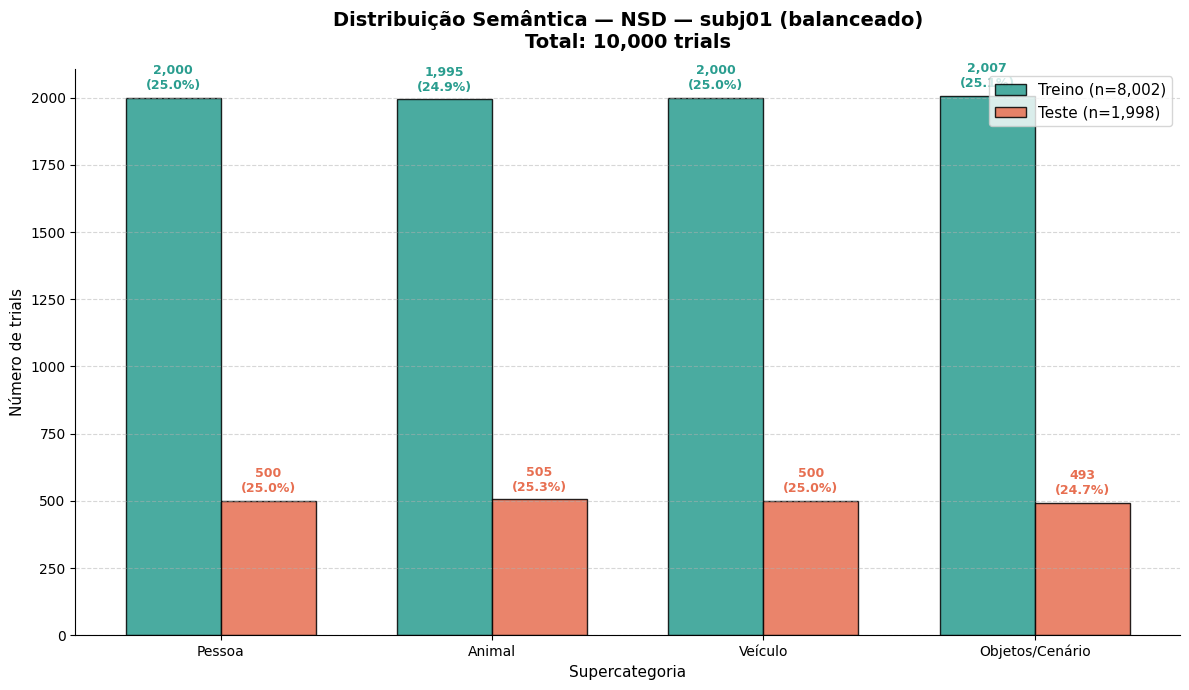

[plot] Salvo em 'nsd_distribution_train_test_nsd_—_subj01_(balanceado).png'


In [ ]:
plot_distribution_train_test(contador_treino, contador_teste, titulo="NSD — subj01 (balanceado)")